# Music Genre Classification - Interaction and binning

## Preparation

### Import necessary libaries

In [8]:
import sys
import pandas as pd
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from model.catboost import catboost
from model.xgboost import xgboost

In [9]:
def heatCorrelation(df):
    plt.figure(figsize=(15,12))
    sns.heatmap(df.corr(),annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()

#### Load the dataset

In [10]:
path_dir = join('..', '..', 'data')
input_dir = join(path_dir, 'feature_engineered','baseline')
train = pd.read_csv(join(input_dir, 'baseline_train.csv'))

test = pd.read_csv(join(input_dir, 'baseline_test.csv'))
train.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,37.0,0.334,-0.676218,9.0,0.153284,0,26.246030,0.723043,0.003912,-0.598627,0.235,1.014464,452.710724,4,9
1,67.0,0.725,0.256062,11.0,0.523145,1,11.415395,0.300739,0.045738,-0.629790,0.380,0.425560,438.127835,4,6
2,44.0,0.584,0.550185,7.0,0.332191,1,16.154828,0.098922,0.139563,1.055408,0.635,1.226456,401.294156,4,10
3,12.0,0.515,-1.433464,-1.0,-1.572682,1,32.050255,0.967986,0.021076,1.134827,0.501,1.563116,545.978937,3,2
4,48.0,0.565,0.408517,6.0,0.691321,0,4.016048,0.567741,0.003912,0.583192,0.619,-1.217968,504.127960,4,5


### Function feature engineering

In [11]:
import pandas as pd
import numpy as np

def func_feature_engineering(old_df):
    df = old_df.copy()

    # ========= Interaction từ heatmap =========
    df["energy_loudness"] = df["energy"] * df["loudness"]
    df["energy_acoustic"] = df["energy"] * (1 - df["acousticness"])
    df["loudness_acoustic"] = df["loudness"] * (1 - df["acousticness"])

    # ========= Semantic feature =========
    df["mood_score"] = (
        0.4 * df["energy"] +
        0.3 * df["valence"] +
        0.3 * df["danceability"]
    )

    # ========= Binning / Cut =========
    # Energy: low / mid / high
    df["energy_bin"] = pd.cut(
        df["energy"],
        bins=[0, 0.4, 0.7, 1.0],
        labels=False,
        include_lowest=True
    )

    # Duration: chia đều theo phân phối
    df["duration_bin"] = pd.qcut(
        df["duration_in min/ms"],
        q=4,
        labels=False,
        duplicates="drop"
    )

    # Popularity: chia 5 mức
    df["popularity_bin"] = pd.qcut(
        df["Popularity"],
        q=5,
        labels=False,
        duplicates="drop"
    )

    return df

df_train = func_feature_engineering(train)
df_test  = func_feature_engineering(test)




Visualize with the feature engineered

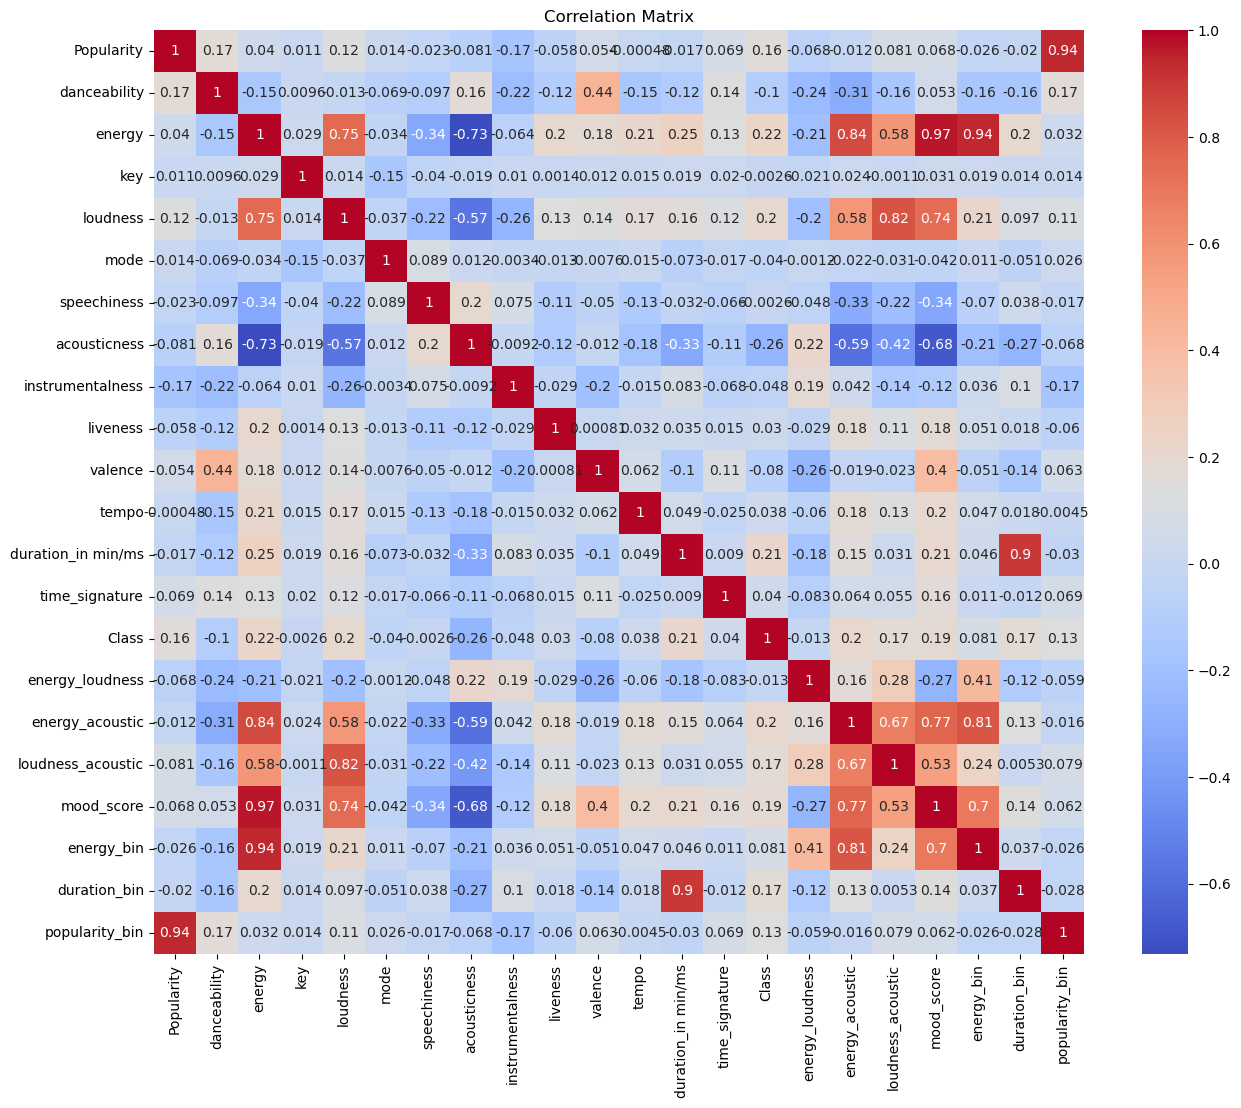

In [12]:
heatCorrelation(df_train)

### Save the csv file

In [13]:
df_train.to_csv(join(path_dir, "feature_engineered", "Interaction_and_binning", "Interaction_and_binning_train.csv"), index=False)
df_test.to_csv (join(path_dir,  "feature_engineered", "Interaction_and_binning", "Interaction_and_binning_test.csv"),  index=False)

### Modeling

In [14]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from model.catboost import catboost
from model.xgboost import xgboost
author_field = "Toan Thang"
FE_field     = "Interaction_and_binning"

catboost(df=df_train, df_test=df_test, author=author_field, path_to_log_csv=join('..', '..', 'log', FE_field, 'experiment_log.csv'), name_folder=FE_field, name_feature=FE_field, print_log=False, save_log=True, save_model=True, save_submission=True)
xgboost(df=df_train, df_test=df_test, author=author_field, path_to_log_csv=join('..', '..', 'log', FE_field, 'experiment_log.csv'), name_folder=FE_field, name_feature=FE_field, print_log=False, save_log=True, save_model=True, save_submission=True)

Logged experiment to ..\..\log\Interaction_and_binning\experiment_log.csv
✅ Model saved to ..\..\log\Interaction_and_binning\Model Pickles\CatBoostClassifier\CatBoostClassifier_Interaction_and_binning.pkl
📤 Submission file saved to ..\..\data\submissions\Interaction_and_binning\CatBoostClassifier\submission_CatBoostClassifier_Interaction_and_binning.csv
Logged experiment to ..\..\log\Interaction_and_binning\experiment_log.csv
✅ Model saved to ..\..\log\Interaction_and_binning\Model Pickles\XGBClassifier\XGBClassifier_Interaction_and_binning.pkl
📤 Submission file saved to ..\..\data\submissions\Interaction_and_binning\XGBClassifier\submission_XGBClassifier_Interaction_and_binning.csv
